# Tutorial: Análisis y Visualización del Dataset de Estudiantes

Este notebook muestra cómo cargar, explorar y visualizar los datos del dataset de estudiantes que incluye información sobre el rendimiento académico en matemáticas y portugués.

## 1. Importar las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración para mejores visualizaciones
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Cargar los datos

In [2]:
# Cargar los datasets
# Nota: Los datos están separados por punto y coma (;)
math_df = pd.read_csv('dataset/student-mat.csv', sep=';')
port_df = pd.read_csv('dataset/student-por.csv', sep=';')

print(f"Dataset de Matemáticas: {math_df.shape[0]} estudiantes, {math_df.shape[1]} variables")
print(f"Dataset de Portugués: {port_df.shape[0]} estudiantes, {port_df.shape[1]} variables")

Dataset de Matemáticas: 395 estudiantes, 33 variables
Dataset de Portugués: 649 estudiantes, 33 variables


## 3. Exploración inicial de los datos

In [3]:
# Información general del dataset de matemáticas
print("=== INFORMACIÓN DEL DATASET DE MATEMÁTICAS ===")
print(math_df.info())
print("\n=== PRIMERAS 5 FILAS ===")
display(math_df.head())

=== INFORMACIÓN DEL DATASET DE MATEMÁTICAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nur

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# Estadísticas descriptivas para variables numéricas
print("=== ESTADÍSTICAS DESCRIPTIVAS - MATEMÁTICAS ===")
display(math_df.describe())

=== ESTADÍSTICAS DESCRIPTIVAS - MATEMÁTICAS ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
# Verificar valores faltantes
print("=== VALORES FALTANTES ===")
missing_math = math_df.isnull().sum()
missing_port = port_df.isnull().sum()

print("Matemáticas:")
print(missing_math[missing_math > 0] if missing_math.sum() > 0 else "No hay valores faltantes")

print("\nPortugués:")
print(missing_port[missing_port > 0] if missing_port.sum() > 0 else "No hay valores faltantes")

=== VALORES FALTANTES ===
Matemáticas:
No hay valores faltantes

Portugués:
No hay valores faltantes


## 4. Visualizaciones básicas

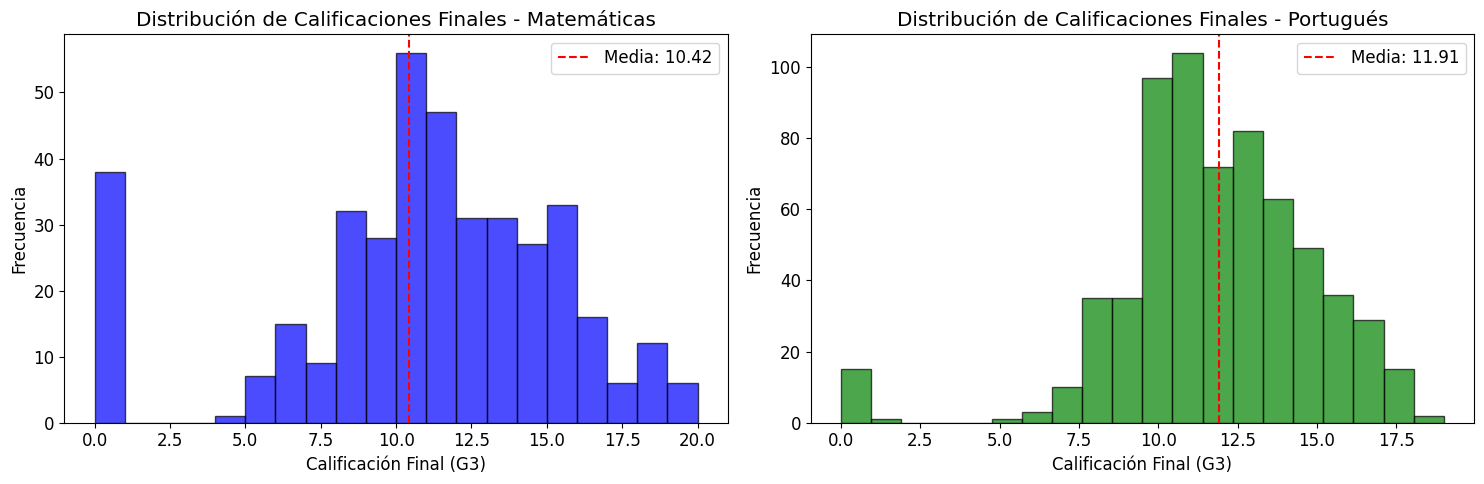

In [8]:
# Distribución de las calificaciones finales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
axes[0].hist(math_df['G3'], bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Distribución de Calificaciones Finales - Matemáticas')
axes[0].set_xlabel('Calificación Final (G3)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(math_df['G3'].mean(), color='red', linestyle='--', label=f'Media: {math_df["G3"].mean():.2f}')
axes[0].legend()

# Portugués
axes[1].hist(port_df['G3'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribución de Calificaciones Finales - Portugués')
axes[1].set_xlabel('Calificación Final (G3)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(port_df['G3'].mean(), color='red', linestyle='--', label=f'Media: {port_df["G3"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

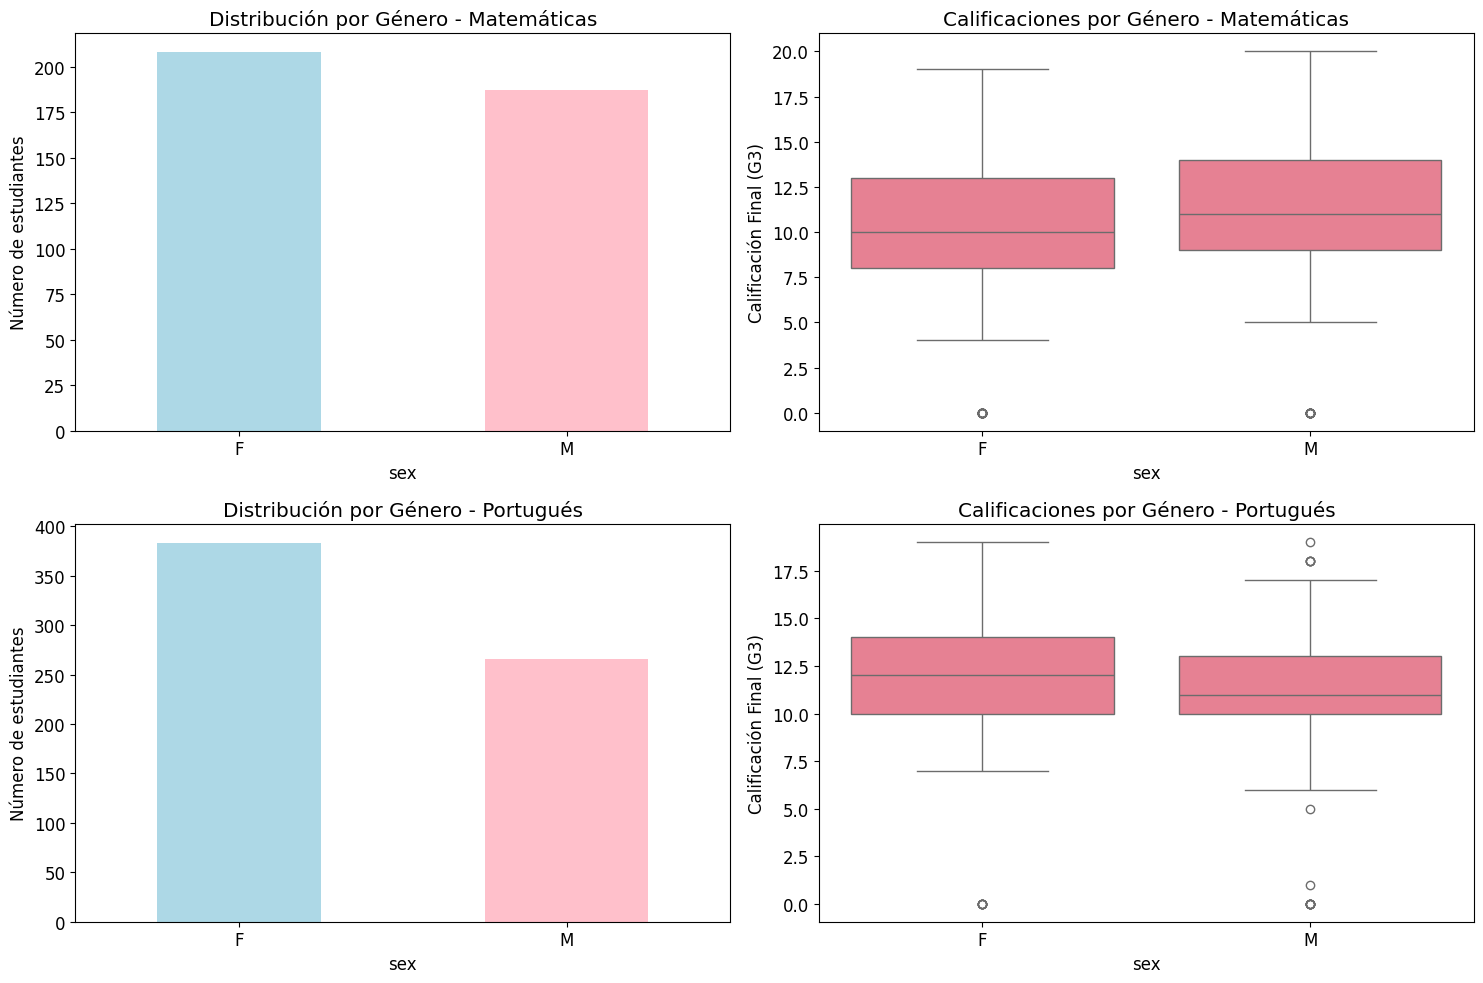

In [9]:
# Distribución por género
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Matemáticas - Conteo por género
math_df['sex'].value_counts().plot(kind='bar', ax=axes[0,0], color=['lightblue', 'pink'])
axes[0,0].set_title('Distribución por Género - Matemáticas')
axes[0,0].set_ylabel('Número de estudiantes')
axes[0,0].tick_params(axis='x', rotation=0)

# Matemáticas - Calificaciones por género
sns.boxplot(data=math_df, x='sex', y='G3', ax=axes[0,1])
axes[0,1].set_title('Calificaciones por Género - Matemáticas')
axes[0,1].set_ylabel('Calificación Final (G3)')

# Portugués - Conteo por género
port_df['sex'].value_counts().plot(kind='bar', ax=axes[1,0], color=['lightblue', 'pink'])
axes[1,0].set_title('Distribución por Género - Portugués')
axes[1,0].set_ylabel('Número de estudiantes')
axes[1,0].tick_params(axis='x', rotation=0)

# Portugués - Calificaciones por género
sns.boxplot(data=port_df, x='sex', y='G3', ax=axes[1,1])
axes[1,1].set_title('Calificaciones por Género - Portugués')
axes[1,1].set_ylabel('Calificación Final (G3)')

plt.tight_layout()
plt.show()

## 5. Análisis de correlaciones

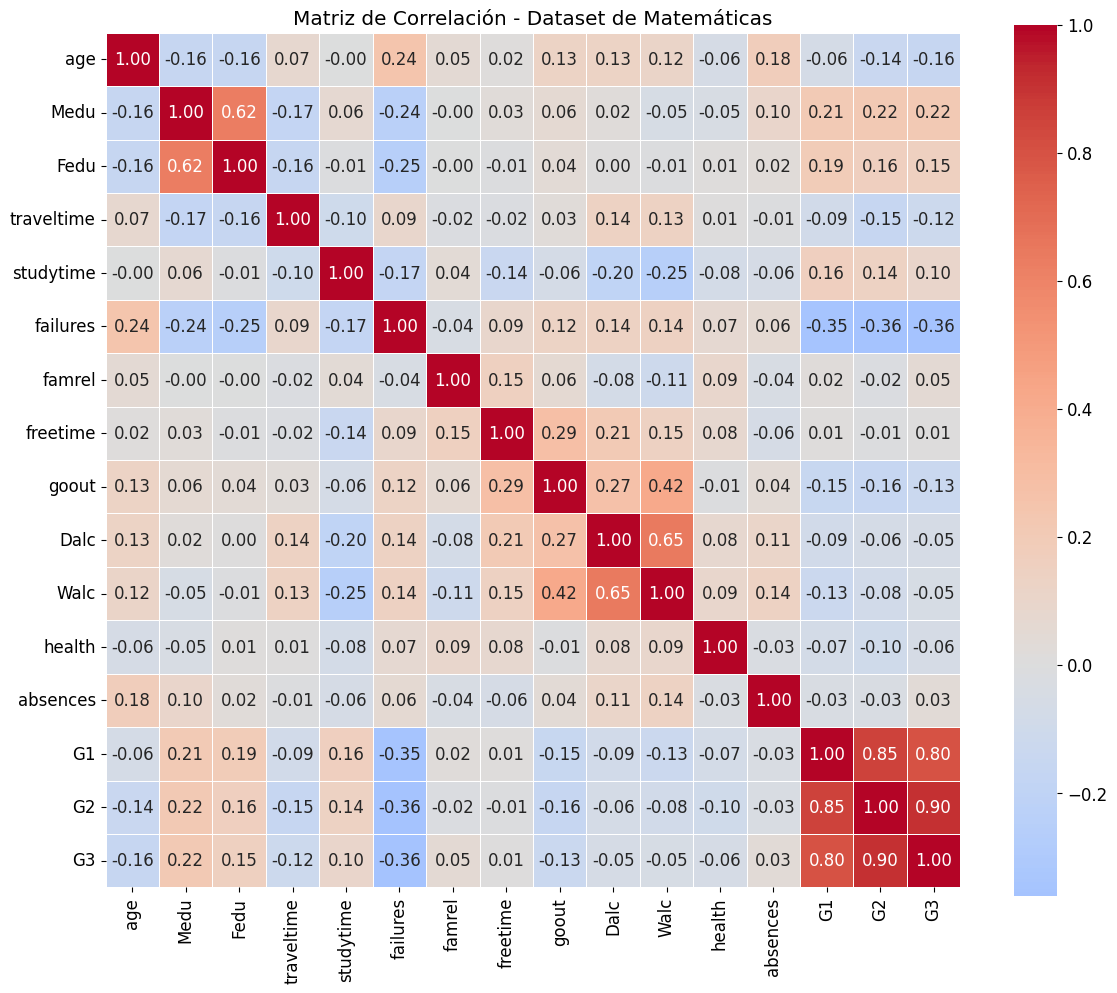

In [10]:
# Seleccionar solo variables numéricas para correlación
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 
                'G1', 'G2', 'G3']

# Matriz de correlación para matemáticas
math_corr = math_df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(math_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Matriz de Correlación - Dataset de Matemáticas')
plt.tight_layout()
plt.show()

In [11]:
# Correlaciones más importantes con G3 (calificación final)
print("=== CORRELACIONES MÁS FUERTES CON LA CALIFICACIÓN FINAL (G3) ===")
print("\nMatemáticas:")
math_g3_corr = math_corr['G3'].sort_values(key=abs, ascending=False)
for var, corr in math_g3_corr.items():
    if var != 'G3':
        print(f"{var}: {corr:.3f}")

print("\nPortugués:")
port_corr = port_df[numeric_cols].corr()
port_g3_corr = port_corr['G3'].sort_values(key=abs, ascending=False)
for var, corr in port_g3_corr.items():
    if var != 'G3':
        print(f"{var}: {corr:.3f}")

=== CORRELACIONES MÁS FUERTES CON LA CALIFICACIÓN FINAL (G3) ===

Matemáticas:
G2: 0.905
G1: 0.801
failures: -0.360
Medu: 0.217
age: -0.162
Fedu: 0.152
goout: -0.133
traveltime: -0.117
studytime: 0.098
health: -0.061
Dalc: -0.055
Walc: -0.052
famrel: 0.051
absences: 0.034
freetime: 0.011

Portugués:
G2: 0.919
G1: 0.826
failures: -0.393
studytime: 0.250
Medu: 0.240
Fedu: 0.212
Dalc: -0.205
Walc: -0.177
traveltime: -0.127
freetime: -0.123
age: -0.107
health: -0.099
absences: -0.091
goout: -0.088
famrel: 0.063


## 6. Análisis de factores que influyen en el rendimiento

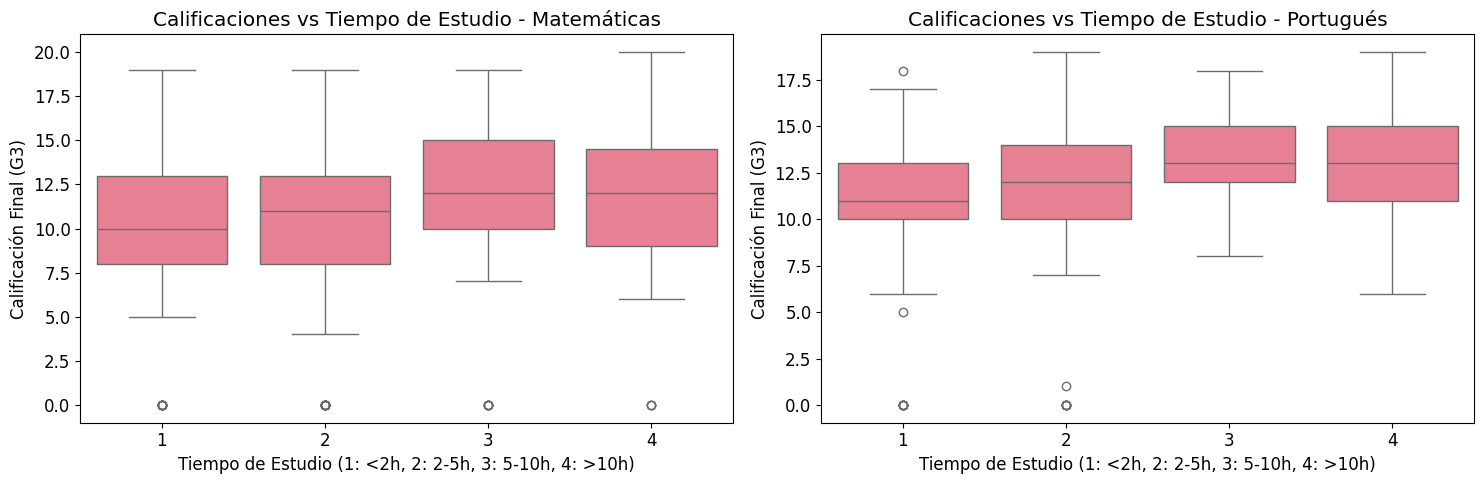

In [12]:
# Efecto del tiempo de estudio en las calificaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
sns.boxplot(data=math_df, x='studytime', y='G3', ax=axes[0])
axes[0].set_title('Calificaciones vs Tiempo de Estudio - Matemáticas')
axes[0].set_xlabel('Tiempo de Estudio (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
axes[0].set_ylabel('Calificación Final (G3)')

# Portugués
sns.boxplot(data=port_df, x='studytime', y='G3', ax=axes[1])
axes[1].set_title('Calificaciones vs Tiempo de Estudio - Portugués')
axes[1].set_xlabel('Tiempo de Estudio (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
axes[1].set_ylabel('Calificación Final (G3)')

plt.tight_layout()
plt.show()

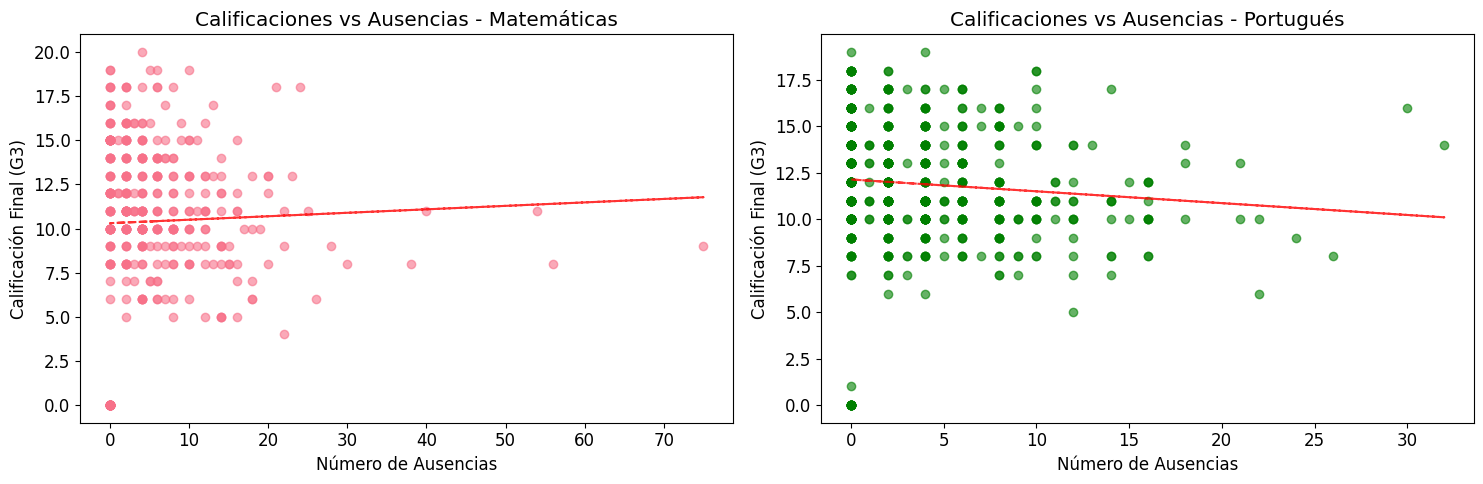

In [13]:
# Efecto de las ausencias en las calificaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
axes[0].scatter(math_df['absences'], math_df['G3'], alpha=0.6)
axes[0].set_title('Calificaciones vs Ausencias - Matemáticas')
axes[0].set_xlabel('Número de Ausencias')
axes[0].set_ylabel('Calificación Final (G3)')

# Agregar línea de tendencia
z = np.polyfit(math_df['absences'], math_df['G3'], 1)
p = np.poly1d(z)
axes[0].plot(math_df['absences'], p(math_df['absences']), "r--", alpha=0.8)

# Portugués
axes[1].scatter(port_df['absences'], port_df['G3'], alpha=0.6, color='green')
axes[1].set_title('Calificaciones vs Ausencias - Portugués')
axes[1].set_xlabel('Número de Ausencias')
axes[1].set_ylabel('Calificación Final (G3)')

# Agregar línea de tendencia
z = np.polyfit(port_df['absences'], port_df['G3'], 1)
p = np.poly1d(z)
axes[1].plot(port_df['absences'], p(port_df['absences']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

## 7. Análisis de variables categóricas importantes

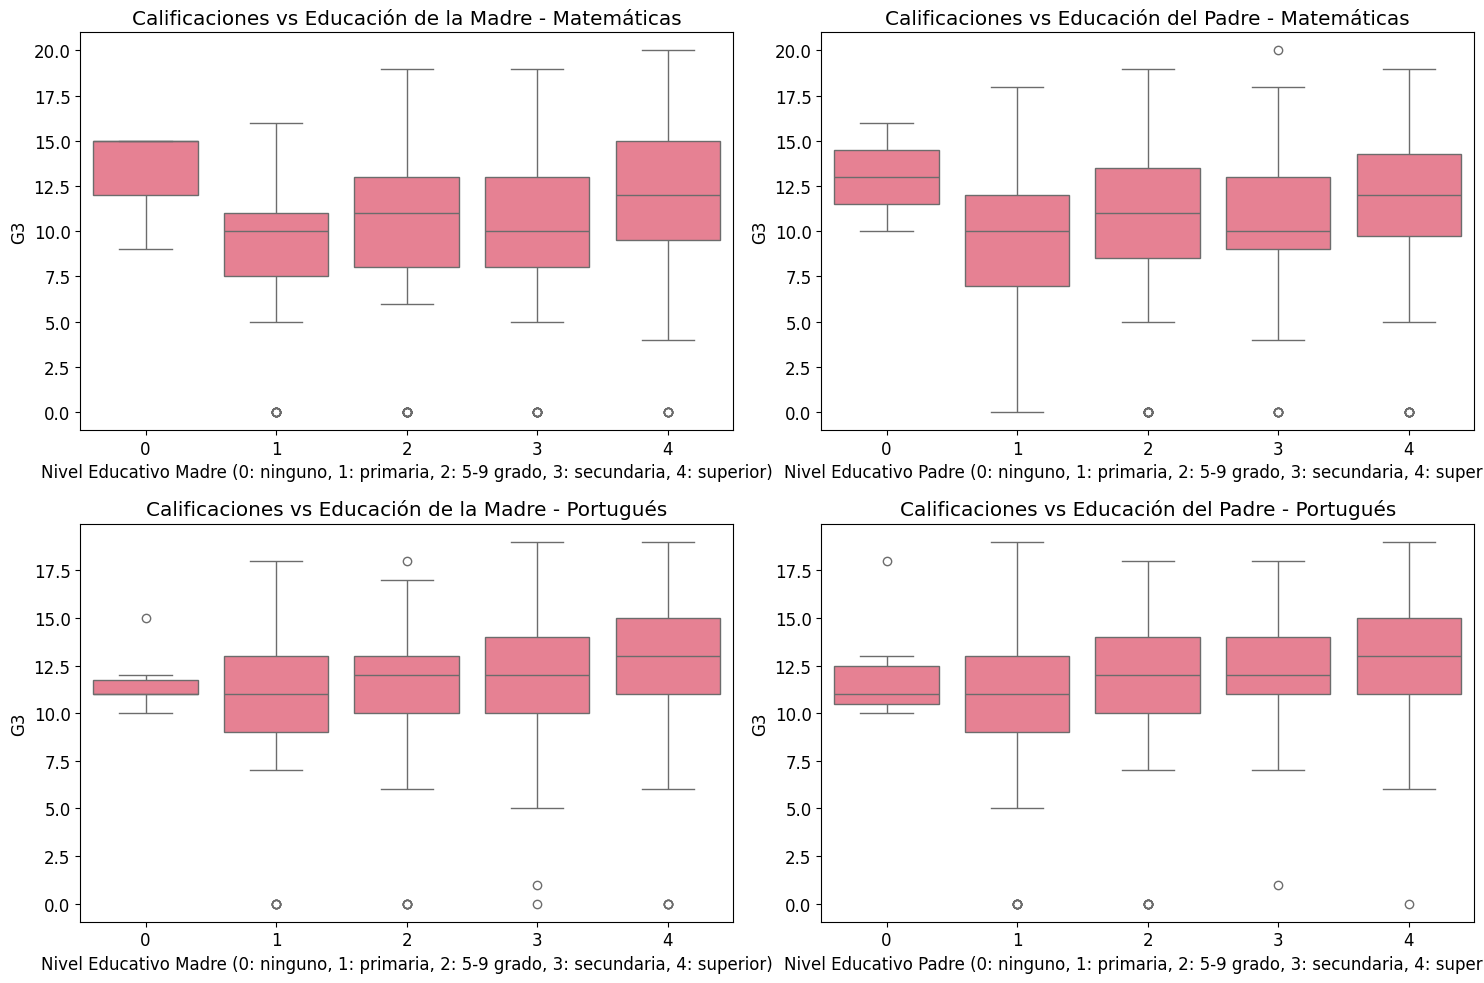

In [14]:
# Efecto del nivel educativo de los padres
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Matemáticas - Educación de la madre
sns.boxplot(data=math_df, x='Medu', y='G3', ax=axes[0,0])
axes[0,0].set_title('Calificaciones vs Educación de la Madre - Matemáticas')
axes[0,0].set_xlabel('Nivel Educativo Madre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Matemáticas - Educación del padre
sns.boxplot(data=math_df, x='Fedu', y='G3', ax=axes[0,1])
axes[0,1].set_title('Calificaciones vs Educación del Padre - Matemáticas')
axes[0,1].set_xlabel('Nivel Educativo Padre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Portugués - Educación de la madre
sns.boxplot(data=port_df, x='Medu', y='G3', ax=axes[1,0])
axes[1,0].set_title('Calificaciones vs Educación de la Madre - Portugués')
axes[1,0].set_xlabel('Nivel Educativo Madre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

# Portugués - Educación del padre
sns.boxplot(data=port_df, x='Fedu', y='G3', ax=axes[1,1])
axes[1,1].set_title('Calificaciones vs Educación del Padre - Portugués')
axes[1,1].set_xlabel('Nivel Educativo Padre (0: ninguno, 1: primaria, 2: 5-9 grado, 3: secundaria, 4: superior)')

plt.tight_layout()
plt.show()

## 8. Comparación entre G1, G2 y G3 (progresión del estudiante)

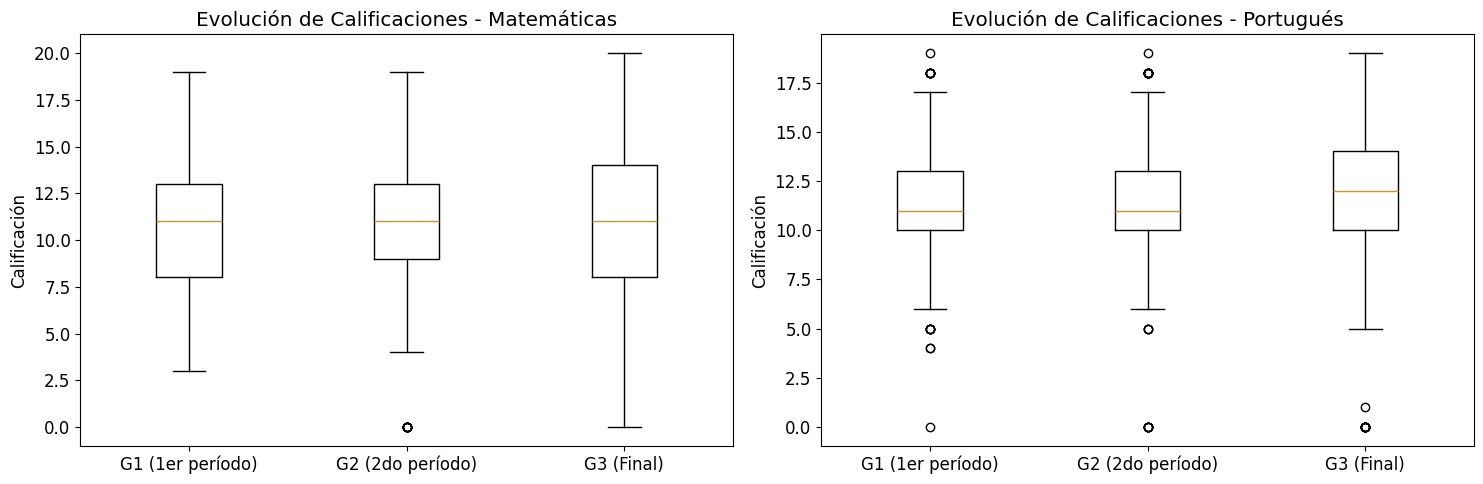

In [15]:
# Evolución de las calificaciones a lo largo del año
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matemáticas
grades_math = math_df[['G1', 'G2', 'G3']]
axes[0].boxplot([grades_math['G1'], grades_math['G2'], grades_math['G3']], 
                labels=['G1 (1er período)', 'G2 (2do período)', 'G3 (Final)'])
axes[0].set_title('Evolución de Calificaciones - Matemáticas')
axes[0].set_ylabel('Calificación')

# Portugués
grades_port = port_df[['G1', 'G2', 'G3']]
axes[1].boxplot([grades_port['G1'], grades_port['G2'], grades_port['G3']], 
                labels=['G1 (1er período)', 'G2 (2do período)', 'G3 (Final)'])
axes[1].set_title('Evolución de Calificaciones - Portugués')
axes[1].set_ylabel('Calificación')

plt.tight_layout()
plt.show()

## 9. Estadísticas resumidas

In [16]:
# Resumen estadístico completo
print("=== RESUMEN ESTADÍSTICO ===")
print(f"\nDataset de Matemáticas ({math_df.shape[0]} estudiantes):")
print(f"  - Calificación promedio final: {math_df['G3'].mean():.2f} ± {math_df['G3'].std():.2f}")
print(f"  - Rango de calificaciones: {math_df['G3'].min()} - {math_df['G3'].max()}")
print(f"  - Estudiantes que aprobaron (G3 ≥ 10): {(math_df['G3'] >= 10).sum()} ({(math_df['G3'] >= 10).mean()*100:.1f}%)")
print(f"  - Género: {math_df['sex'].value_counts()['F']} mujeres, {math_df['sex'].value_counts()['M']} hombres")

print(f"\nDataset de Portugués ({port_df.shape[0]} estudiantes):")
print(f"  - Calificación promedio final: {port_df['G3'].mean():.2f} ± {port_df['G3'].std():.2f}")
print(f"  - Rango de calificaciones: {port_df['G3'].min()} - {port_df['G3'].max()}")
print(f"  - Estudiantes que aprobaron (G3 ≥ 10): {(port_df['G3'] >= 10).sum()} ({(port_df['G3'] >= 10).mean()*100:.1f}%)")
print(f"  - Género: {port_df['sex'].value_counts()['F']} mujeres, {port_df['sex'].value_counts()['M']} hombres")

=== RESUMEN ESTADÍSTICO ===

Dataset de Matemáticas (395 estudiantes):
  - Calificación promedio final: 10.42 ± 4.58
  - Rango de calificaciones: 0 - 20
  - Estudiantes que aprobaron (G3 ≥ 10): 265 (67.1%)
  - Género: 208 mujeres, 187 hombres

Dataset de Portugués (649 estudiantes):
  - Calificación promedio final: 11.91 ± 3.23
  - Rango de calificaciones: 0 - 19
  - Estudiantes que aprobaron (G3 ≥ 10): 549 (84.6%)
  - Género: 383 mujeres, 266 hombres


## 10. Función para análisis personalizado

In [ ]:
def analizar_variable(dataset, variable, target='G3', titulo=None):
    """
    Función para analizar el efecto de una variable en las calificaciones
    
    Parámetros:
    - dataset: DataFrame (math_df o port_df)
    - variable: nombre de la variable a analizar
    - target: variable objetivo (por defecto G3)
    - titulo: título personalizado para el gráfico
    """
    if titulo is None:
        titulo = f'Análisis de {variable} vs {target}'
    
    plt.figure(figsize=(12, 5))
    
    # Si la variable es numérica, hacer scatter plot
    if dataset[variable].dtype in ['int64', 'float64']:
        plt.subplot(1, 2, 1)
        plt.scatter(dataset[variable], dataset[target], alpha=0.6)
        plt.xlabel(variable)
        plt.ylabel(target)
        plt.title(f'Dispersión: {variable} vs {target}')
        
        # Correlación
        corr = dataset[variable].corr(dataset[target])
        plt.text(0.05, 0.95, f'Correlación: {corr:.3f}', 
                transform=plt.gca().transAxes, bbox=dict(boxstyle='round', facecolor='wheat'))
        
        plt.subplot(1, 2, 2)
        sns.boxplot(data=dataset, x=variable, y=target)
        plt.title(f'Boxplot: {variable} vs {target}')
    
    # Si la variable es categórica, hacer boxplot y barplot
    else:
        plt.subplot(1, 2, 1)
        sns.boxplot(data=dataset, x=variable, y=target)
        plt.title(f'Distribución de {target} por {variable}')
        plt.xticks(rotation=45)
        
        plt.subplot(1, 2, 2)
        dataset.groupby(variable)[target].mean().plot(kind='bar')
        plt.title(f'Promedio de {target} por {variable}')
        plt.ylabel(f'Promedio {target}')
        plt.xticks(rotation=45)
    
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticas
    if dataset[variable].dtype not in ['int64', 'float64']:
        print("Estadísticas por categoría:")
        stats_df = dataset.groupby(variable)[target].agg(['count', 'mean', 'std']).round(2)
        display(stats_df)

# Ejemplo de uso
print("Ejemplo: Analizar el efecto del consumo de alcohol en fin de semana (Walc) en matemáticas")
analizar_variable(math_df, 'Walc', 'G3', 'Efecto del Alcohol en Fin de Semana - Matemáticas')

## Conclusiones y siguientes pasos

Con este análisis has aprendido a:

1. **Cargar los datos** usando `pd.read_csv()` con el separador correcto (`;`)
2. **Explorar la estructura** con `.info()`, `.describe()`, y `.head()`
3. **Visualizar distribuciones** con histogramas y boxplots
4. **Analizar correlaciones** entre variables numéricas
5. **Comparar grupos** usando variables categóricas
6. **Crear funciones personalizadas** para análisis repetitivos

### Variables más importantes identificadas:
- **G1 y G2**: Calificaciones de períodos anteriores (fuerte predictor de G3)
- **Failures**: Número de suspensos previos (correlación negativa)
- **Studytime**: Tiempo de estudio semanal
- **Medu/Fedu**: Nivel educativo de los padres
- **Absences**: Número de ausencias

### Próximos pasos sugeridos:
1. Crear modelos predictivos para G3
2. Analizar los estudiantes que están en ambos datasets
3. Realizar análisis de clustering para identificar perfiles de estudiantes
4. Estudiar la evolución G1 → G2 → G3 más detalladamente